In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

data = pd.read_csv(
    "Objective2_L2.csv"
)

data["Date"] = pd.to_datetime(
    data["Date"],
    dayfirst=True
)

data = data.sort_values(
    "Match_ID"
).reset_index(drop=True)

print("Matches:", len(data))

Matches: 104


In [2]:
team_state = {}

def new_team_state():
    return {
        "matches": 0,
        "goals_for": 0,
        "goals_against": 0,
        "wins": 0,
        "clean_sheets": 0,
        "failed_to_score": 0,
        "fouls_sum": 0,
        "foul_matches": 0,
        "last_date": None
    }


def get_stats(team, match_date):

    if team not in team_state:
        team_state[team] = new_team_state()

    s = team_state[team]

    if s["matches"] == 0:

        avg_gf = 0
        avg_ga = 0
        win_rate = 0
        clean_rate = 0
        fail_rate = 0

    else:

        avg_gf = (
            s["goals_for"]
            / s["matches"]
        )

        avg_ga = (
            s["goals_against"]
            / s["matches"]
        )

        win_rate = (
            s["wins"]
            / s["matches"]
        )

        clean_rate = (
            s["clean_sheets"]
            / s["matches"]
        )

        fail_rate = (
            s["failed_to_score"]
            / s["matches"]
        )

    if s["foul_matches"] == 0:
        avg_fouls = 0
    else:
        avg_fouls = (
            s["fouls_sum"]
            / s["foul_matches"]
        )

    if s["last_date"] is None:
        rest_days = 0
    else:
        rest_days = (
            match_date
            -
            s["last_date"]
        ).days

    return {
        "avg_gf": avg_gf,
        "avg_ga": avg_ga,
        "win_rate": win_rate,
        "clean_rate": clean_rate,
        "fail_rate": fail_rate,
        "avg_fouls": avg_fouls,
        "rest_days": rest_days
    }

In [3]:
def update_state(
    team,
    goals_for,
    goals_against,
    fouls,
    match_date
):

    s = team_state[team]

    s["matches"] += 1

    s["goals_for"] += goals_for
    s["goals_against"] += goals_against

    if goals_for > goals_against:
        s["wins"] += 1

    if goals_against == 0:
        s["clean_sheets"] += 1

    if goals_for == 0:
        s["failed_to_score"] += 1

    if pd.notna(fouls):

        s["fouls_sum"] += fouls
        s["foul_matches"] += 1

    s["last_date"] = match_date

In [4]:
rows_208 = []

for _, match in data.iterrows():

    date = match["Date"]

    team1 = match["Team1"]
    team2 = match["Team2"]

    t1 = get_stats(
        team1,
        date
    )

    t2 = get_stats(
        team2,
        date
    )

    # Team 1 observation
    rows_208.append(
        {
            "Match_ID": match["Match_ID"],
            "Team": team1,
            "Opponent": team2,

            "Goals_Scored":
                match["Team1_Goals"],

            "Pre_Avg_GF":
                t1["avg_gf"],

            "Pre_Avg_GA":
                t1["avg_ga"],

            "Pre_Win_Rate":
                t1["win_rate"],

            "Pre_Clean_Sheet_Rate":
                t1["clean_rate"],

            "Pre_Failed_To_Score_Rate":
                t1["fail_rate"],

            "Pre_Avg_Fouls":
                t1["avg_fouls"],

            "Rest_Days":
                t1["rest_days"],

            "Opponent_Pre_Avg_GA":
                t2["avg_ga"]
        }
    )

    # Team 2 observation
    rows_208.append(
        {
            "Match_ID": match["Match_ID"],
            "Team": team2,
            "Opponent": team1,

            "Goals_Scored":
                match["Team2_Goals"],

            "Pre_Avg_GF":
                t2["avg_gf"],

            "Pre_Avg_GA":
                t2["avg_ga"],

            "Pre_Win_Rate":
                t2["win_rate"],

            "Pre_Clean_Sheet_Rate":
                t2["clean_rate"],

            "Pre_Failed_To_Score_Rate":
                t2["fail_rate"],

            "Pre_Avg_Fouls":
                t2["avg_fouls"],

            "Rest_Days":
                t2["rest_days"],

            "Opponent_Pre_Avg_GA":
                t1["avg_ga"]
        }
    )

    # Update only AFTER both rows are constructed
    update_state(
        team1,
        match["Team1_Goals"],
        match["Team2_Goals"],
        match["Team1_Fouls"],
        date
    )

    update_state(
        team2,
        match["Team2_Goals"],
        match["Team1_Goals"],
        match["Team2_Fouls"],
        date
    )


regression_22 = pd.DataFrame(
    rows_208
)

print(
    "Dataset shape:",
    regression_22.shape
)

display(
    regression_22.head(10)
)

Dataset shape: (208, 12)


,Match_ID,Team,Opponent,Goals_Scored,Pre_Avg_GF,Pre_Avg_GA,Pre_Win_Rate,Pre_Clean_Sheet_Rate,Pre_Failed_To_Score_Rate,Pre_Avg_Fouls,Rest_Days,Opponent_Pre_Avg_GA
0,1,Mexico,South Africa,2,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
1,1,South Africa,Mexico,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
2,2,South Korea,Czech Republic,2,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
3,2,Czech Republic,South Korea,1,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
4,3,Canada,Bosnia & Herzegovina,1,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
5,3,Bosnia & Herzegovina,Canada,1,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
6,4,USA,Paraguay,4,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
7,4,Paraguay,USA,1,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
8,5,Qatar,Switzerland,1,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
9,5,Switzerland,Qatar,1,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0


In [5]:
features_22 = [
    "Pre_Avg_GF",
    "Pre_Avg_GA",
    "Pre_Win_Rate",
    "Pre_Clean_Sheet_Rate",
    "Pre_Failed_To_Score_Rate",
    "Pre_Avg_Fouls",
    "Rest_Days",
    "Opponent_Pre_Avg_GA"
]

print(
    "Number of explanatory variables:",
    len(features_22)
)

print(
    "\nMissing predictor values:"
)

print(
    regression_22[
        features_22
    ].isnull().sum()
)

Number of explanatory variables: 8

Missing predictor values:
Pre_Avg_GF                  0
Pre_Avg_GA                  0
Pre_Win_Rate                0
Pre_Clean_Sheet_Rate        0
Pre_Failed_To_Score_Rate    0
Pre_Avg_Fouls               0
Rest_Days                   0
Opponent_Pre_Avg_GA         0
dtype: int64


In [6]:
regression_22.to_csv(
    "objective2_regression_2_2_dataset.csv",
    index=False
)

print("Regression 2.2 dataset saved.")

Regression 2.2 dataset saved.


In [7]:
X = regression_22[
    features_22
]

y = regression_22[
    "Goals_Scored"
]

In [8]:
train_mask = (
    regression_22["Match_ID"] <= 83
)

test_mask = (
    regression_22["Match_ID"] > 83
)

X_train = X[
    train_mask
]

X_test = X[
    test_mask
]

y_train = y[
    train_mask
]

y_test = y[
    test_mask
]

print(
    "Training rows:",
    len(X_train)
)

print(
    "Testing rows:",
    len(X_test)
)

print(
    "Training matches:",
    regression_22.loc[
        train_mask,
        "Match_ID"
    ].nunique()
)

print(
    "Testing matches:",
    regression_22.loc[
        test_mask,
        "Match_ID"
    ].nunique()
)

Training rows: 166
Testing rows: 42
Training matches: 83
Testing matches: 21


In [9]:
model_22 = LinearRegression()

model_22.fit(
    X_train,
    y_train
)

predictions_22 = model_22.predict(
    X_test
)

In [10]:
mae_22 = mean_absolute_error(
    y_test,
    predictions_22
)

rmse_22 = np.sqrt(
    mean_squared_error(
        y_test,
        predictions_22
    )
)

r2_22 = r2_score(
    y_test,
    predictions_22
)

print(
    "MAE:",
    round(mae_22, 3)
)

print(
    "RMSE:",
    round(rmse_22, 3)
)

print(
    "R-squared:",
    round(r2_22, 3)
)

MAE: 1.003
RMSE: 1.358
R-squared: -0.069


In [11]:
baseline_predictions = np.repeat(
    y_train.mean(),
    len(y_test)
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print(
    "Baseline MAE:",
    round(baseline_mae, 3)
)

print(
    "Baseline RMSE:",
    round(baseline_rmse, 3)
)

print(
    "Baseline R-squared:",
    round(baseline_r2, 3)
)

Baseline MAE: 1.045
Baseline RMSE: 1.315
Baseline R-squared: -0.001


In [12]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Linear Regression",
            "Mean Baseline"
        ],
        "MAE": [
            mae_22,
            baseline_mae
        ],
        "RMSE": [
            rmse_22,
            baseline_rmse
        ],
        "R2": [
            r2_22,
            baseline_r2
        ]
    }
)

display(
    comparison.round(3)
)

,Model,MAE,RMSE,R2
0,Linear Regression,1.003,1.358,-0.069
1,Mean Baseline,1.045,1.315,-0.001


In [13]:
coefficients_22 = pd.DataFrame(
    {
        "Variable": features_22,
        "Coefficient":
            model_22.coef_
    }
)

coefficients_22 = (
    coefficients_22
    .sort_values(
        "Coefficient",
        key=abs,
        ascending=False
    )
)

display(
    coefficients_22.round(3)
)

print(
    "Intercept:",
    round(
        model_22.intercept_,
        3
    )
)

,Variable,Coefficient
2,Pre_Win_Rate,-1.260
3,Pre_Clean_Sheet_Rate,0.447
4,Pre_Failed_To_Score_Rate,-0.446
0,Pre_Avg_GF,0.330
7,Opponent_Pre_Avg_GA,0.328
1,Pre_Avg_GA,-0.300
5,Pre_Avg_Fouls,-0.036
6,Rest_Days,0.021


Intercept: 1.593


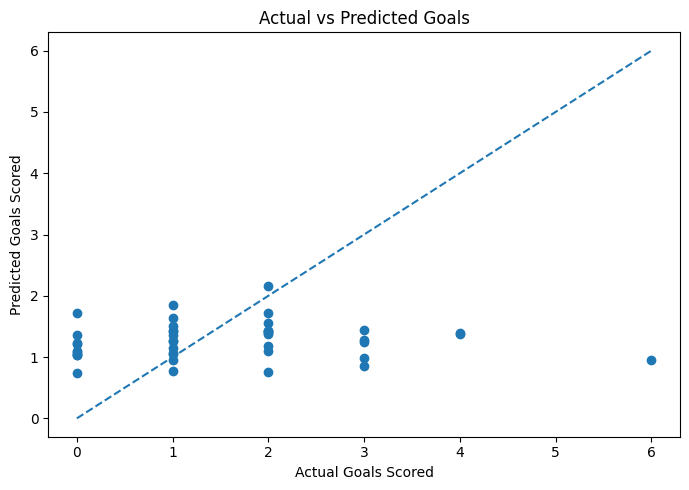

In [14]:
plt.figure(
    figsize=(7, 5)
)

plt.scatter(
    y_test,
    predictions_22
)

minimum = min(
    y_test.min(),
    predictions_22.min()
)

maximum = max(
    y_test.max(),
    predictions_22.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Goals Scored"
)

plt.ylabel(
    "Predicted Goals Scored"
)

plt.title(
    "Actual vs Predicted Goals"
)

plt.tight_layout()
plt.show()

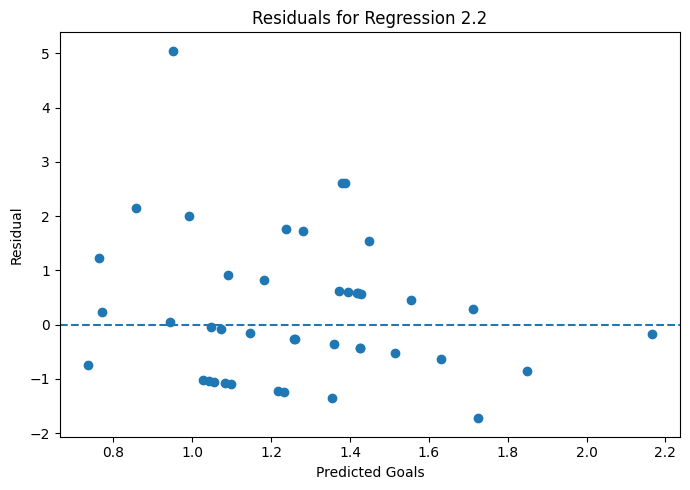

In [15]:
residuals_22 = (
    y_test
    -
    predictions_22
)

plt.figure(
    figsize=(7, 5)
)

plt.scatter(
    predictions_22,
    residuals_22
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Goals"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residuals for Regression 2.2"
)

plt.tight_layout()
plt.show()

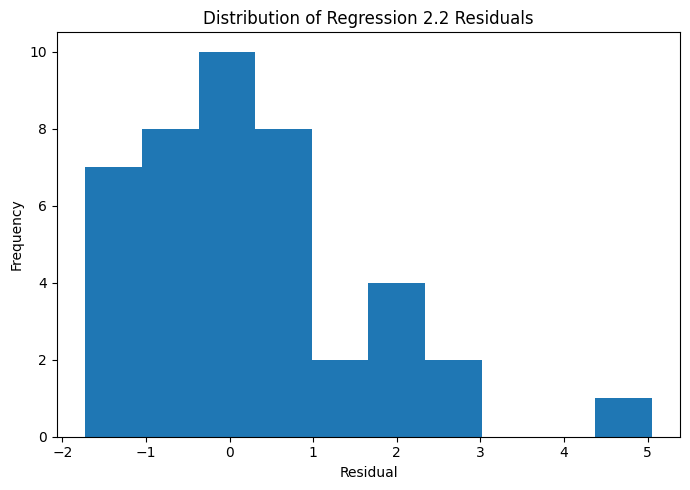

In [16]:
plt.figure(
    figsize=(7, 5)
)

plt.hist(
    residuals_22,
    bins=10
)

plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Regression 2.2 Residuals"
)

plt.tight_layout()
plt.show()